C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Yahya\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

--- Starting IMPROVED Training for 2000 Epochs ---


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0/2000 [D loss: 0.6941, acc.: 41.02%] [G loss: 0.7239]
Epoch 100/2000 [D loss: 0.6931, acc.: 50.79%] [G loss: 0.6979]
Epoch 200/2000 [D loss: 0.6913, acc.: 55.24%] [G loss: 0.6968]
Epoch 300/2000 [D loss: 0.6913, acc.: 53.67%] [G loss: 0.6963]
Epoch 400/2000 [D loss: 0.6917, acc.: 51.18%] [G loss: 0.6959]
Epoch 500/2000 [D loss: 0.6919, acc.: 49.46%] [G loss: 0.6957]
Epoch 600/2000 [D loss: 0.6921, acc.: 48.23%] [G loss: 0.6956]
Epoch 700/2000 [D loss: 0.6922, acc.: 47.46%] [G loss: 0.6954]
Epoch 800/2000 [D loss: 0.6923, acc.: 46.89%] [G loss: 0.6952]
Epoch 900/2000 [D loss: 0.6924, acc.: 46.50%] [G loss: 0.6951]
Epoch 1000/2000 [D loss: 0.6925, acc.: 46.08%] [G loss: 0.6949]
Epoch 1100/2000 [D loss: 0.6925, acc.: 45.69%] [G loss: 0.6948]
Epoch 1200/2000 [D loss: 0.6926, acc.: 45.29%] [G loss: 0.6947]
Epoch 1300/2000 [D loss: 0.6927, acc.: 44.93%] [G loss: 0.6946]
Epoch 1400/2000 [D loss: 0.6928, acc.: 44.50%] [G loss: 0.6945]
Epoch 1500/2000 [D loss: 0.6928, acc.: 44.13%] [G lo

--- Training Complete in 7.53 minutes ---
Improved Generator Saved to c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Machine Learning & Deep Learning in Finance\Generative Adversarial Networks (GANs) for Market Simulation\models


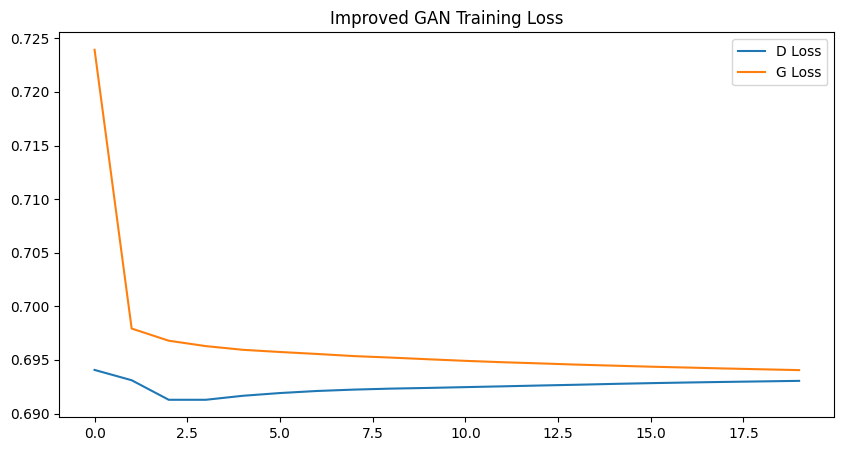

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, LeakyReLU, Input, Reshape, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

# --- Configuration ---
EPOCHS = 2000        
BATCH_SIZE = 64      # Increased batch size for stability
SAMPLE_INTERVAL = 200 

# Paths
BASE_PATH = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
IMAGE_PATH = os.path.join(BASE_PATH, 'images')

# Load Data
X_train = np.load(os.path.join(DATA_PATH, 'training_data.npy'))
SEQ_LEN = 60
LATENT_DIM = 100

# --- IMPROVED ARCHITECTURE ---

def build_generator():
    # We add BatchNormalization to prevent the "Flat Line" saturation issue
    model = Sequential([
        Input(shape=(LATENT_DIM,)),
        Dense(SEQ_LEN * 128),
        BatchNormalization(),        
        LeakyReLU(alpha=0.2),
        Reshape((SEQ_LEN, 128)),
        
        LSTM(128, return_sequences=True),
        BatchNormalization(),        
        
        LSTM(64, return_sequences=True),
        BatchNormalization(),        
        
        # Final layer
        Dense(1, activation='tanh')
    ])
    return model

def build_discriminator():
    model = Sequential([
        Input(shape=(SEQ_LEN, 1)),
        
        LSTM(64, return_sequences=True),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),                
        
        LSTM(32),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),                
        
        Dense(1, activation='sigmoid')
    ])
    # Lower learning rate slightly for stability
    optimizer = Adam(0.0001, 0.5) 
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Initialize
generator = build_generator()
discriminator = build_discriminator()

# Compile Combined
discriminator.trainable = False
gan_input = Input(shape=(LATENT_DIM,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0001, 0.5))

# --- TRAINING LOOP ---
real = np.ones((BATCH_SIZE, 1))
fake = np.zeros((BATCH_SIZE, 1))
d_losses = []
g_losses = []

print(f"--- Starting IMPROVED Training for {EPOCHS} Epochs ---")
start_time = time.time()

for epoch in range(EPOCHS):
    # 1. Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], BATCH_SIZE)
    real_seqs = X_train[idx]
    
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    gen_seqs = generator.predict(noise, verbose=0)
    
    d_loss_real = discriminator.train_on_batch(real_seqs, real)
    d_loss_fake = discriminator.train_on_batch(gen_seqs, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # 2. Train Generator
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, real) 

    # Logging
    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{EPOCHS} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
        d_losses.append(d_loss[0])
        g_losses.append(g_loss)

    # Save Checkpoints
    if epoch % SAMPLE_INTERVAL == 0:
        plt.figure(figsize=(10, 4))
        plt.plot(gen_seqs[0], label="Generated (Fake)")
        plt.plot(real_seqs[0], label="Real Market Data", alpha=0.6)
        plt.title(f"Improved Generator Output at Epoch {epoch}")
        plt.legend()
        # Save with a new prefix 'improved_'
        plt.savefig(os.path.join(IMAGE_PATH, f"improved_epoch_{epoch}.png"))
        plt.close()

end_time = time.time()
print(f"--- Training Complete in {(end_time - start_time)/60:.2f} minutes ---")

# Save the Improved Model
generator.save(os.path.join(MODEL_PATH, 'generator_improved.h5'))
print(f"Improved Generator Saved to {MODEL_PATH}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="D Loss")
plt.plot(g_losses, label="G Loss")
plt.title("Improved GAN Training Loss")
plt.legend()
plt.savefig(os.path.join(IMAGE_PATH, "improved_loss_history.png"))